In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt

# EDA

In [6]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')

# Quick look at training data
print("Training Data Shape:", train.shape)
print("\nFirst 5 rows:")
train.head()

Training Data Shape: (594194, 21)

First 5 rows:


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [9]:
print("Data Types and Missing Values:")
print(train.info())

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  ob

In [10]:
print("Basic Statistics:")
print(train.describe())

Basic Statistics:
                  id  SeniorCitizen         tenure  MonthlyCharges  \
count  594194.000000  594194.000000  594194.000000   594194.000000   
mean   297096.500000       0.114102      36.577258       65.866223   
std    171529.177262       0.317936      25.061922       31.067444   
min         0.000000       0.000000       1.000000       18.250000   
25%    148548.250000       0.000000      12.000000       29.900000   
50%    297096.500000       0.000000      35.000000       74.100000   
75%    445644.750000       0.000000      62.000000       90.800000   
max    594193.000000       1.000000      72.000000      118.750000   

        TotalCharges  
count  594194.000000  
mean     2494.377057  
std      2353.916710  
min        18.800000  
25%       639.650000  
50%      1433.650000  
75%      4263.800000  
max      8684.800000  


In [11]:
print("Target Distribution:")
print(train['Churn'].value_counts(normalize=True))

Target Distribution:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


In [12]:
# Save ids and target
train_id = train['id']
test_id = test['id']
y = (train['Churn'] == 'Yes').astype(int)

# Drop id and target from features
train = train.drop(['id', 'Churn'], axis=1)
test = test.drop('id', axis=1)

# --- Feature Engineering (same as before) ---
def engineer_features(df):
    df = df.copy()
    # Tenure groups
    df['tenure_group'] = pd.cut(df['tenure'], bins=[0,6,12,24,48,100], labels=['0-6','6-12','12-24','24-48','48+'])
    # Avg monthly
    df['avg_monthly'] = df['TotalCharges'] / df['tenure'].replace(0, 1)
    # Binary flags for services
    service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    for col in service_cols:
        df[col + '_bin'] = (df[col] == 'Yes').astype(int)
    df['service_count'] = df[[col+'_bin' for col in service_cols]].sum(axis=1)
    df['has_internet'] = (df['InternetService'] != 'No').astype(int)
    # Polynomials
    df['tenure_sq'] = df['tenure'] ** 2
    df['monthly_sq'] = df['MonthlyCharges'] ** 2
    df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']
    return df

train_fe = engineer_features(train)
test_fe = engineer_features(test)

# --- Encode all categoricals (including new ones) ---
# Combine for consistent encoding
combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

# Identify object columns
cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Label encode each
for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

# Split back
train_enc = combined.iloc[:len(train_fe)].copy()
test_enc = combined.iloc[len(train_fe):].copy()

# Add target back to train_enc (optional)
train_enc['Churn'] = y.values

# Verify all columns are numeric
print("\nData types after encoding:")
print(train_enc.dtypes.value_counts())

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data types after encoding:
int64       29
float64      5
category     1
Name: count, dtype: int64


In [13]:
# Combine train_fe and test_fe
combined = pd.concat([train_fe, test_fe], axis=0, ignore_index=True)

# Encode ALL categorical columns in combined (both object and category dtypes)
# First, handle object columns with LabelEncoder
from sklearn.preprocessing import LabelEncoder

cat_cols = combined.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    le = LabelEncoder()
    combined[col] = le.fit_transform(combined[col].astype(str))

# Convert any pandas 'category' columns to integer codes (e.g., tenure_group)
cat_dtype_cols = combined.select_dtypes(include=['category']).columns.tolist()
for col in cat_dtype_cols:
    combined[col] = combined[col].cat.codes

#  Now split back into train_enc and test_enc
train_enc = combined.iloc[:len(train_fe)].copy()
test_enc = combined.iloc[len(train_fe):].copy()

# Add target back to train_enc (using y from original train)
# (Make sure y is defined; if not, reload: original_train = pd.read_csv(...); y = (original_train['Churn'] == 'Yes').astype(int))
train_enc['Churn'] = y.values

# Verify all columns are numeric
print("Data types after encoding:")
print(train_enc.dtypes.value_counts())
print("\nAny missing values?", train_enc.isnull().any().any())

Data types after encoding:
int64      29
float64     5
int8        1
Name: count, dtype: int64

Any missing values? False


# LogisticRegression

In [14]:
original_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
                     'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                     'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                     'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                     'MonthlyCharges', 'TotalCharges']

X_base = train_enc[original_features]
y = train_enc['Churn']

# Scale numerical features (important for logistic regression)
num_cols_base = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']  # SeniorCitizen is binary but scaling won't hurt
scaler = StandardScaler()
X_base[num_cols_base] = scaler.fit_transform(X_base[num_cols_base])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_base = []

for train_idx, val_idx in skf.split(X_base, y):
    X_tr, X_val = X_base.iloc[train_idx], X_base.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)
    cv_scores_base.append(auc)

print(f"Baseline CV AUC: {np.mean(cv_scores_base):.5f} (+/- {np.std(cv_scores_base):.5f})")

/tmp/ipykernel_55/3490345152.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_base[num_cols_base] = scaler.fit_transform(X_base[num_cols_base])


Baseline CV AUC: 0.90511 (+/- 0.00100)


In [15]:
# Define features (exclude target)
feature_cols = [col for col in train_enc.columns if col != 'Churn']
X = train_enc[feature_cols].copy()
y = train_enc['Churn'].copy()

# Scale all numeric features (optional but recommended for logistic regression)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Cross-validation with same folds as baseline for fair comparison
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in skf.split(X_scaled, y):
    X_tr, X_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_tr, y_tr)
    pred = model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, pred)
    cv_scores.append(auc)

print(f"Full Feature CV AUC: {np.mean(cv_scores):.5f} (+/- {np.std(cv_scores):.5f})")

Full Feature CV AUC: 0.90769 (+/- 0.00099)


In [16]:
# Train on full data
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)  # X_scaled is the scaled full feature set

# Create dataframe of feature importance
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef': model.coef_[0],
    'abs_coef': np.abs(model.coef_[0])
}).sort_values('abs_coef', ascending=False)

print(coef_df.head(15))

                feature      coef  abs_coef
4                tenure -2.068147  2.068147
31            tenure_sq  1.994413  1.994413
33     tenure_x_monthly -1.816949  1.816949
32           monthly_sq  1.204361  1.204361
18         TotalCharges  1.067282  1.067282
14             Contract -1.032283  1.032283
30         has_internet  0.857569  0.857569
7       InternetService  0.722313  0.722313
17       MonthlyCharges -0.720506  0.720506
8        OnlineSecurity -0.325780  0.325780
11          TechSupport -0.290966  0.290966
27      StreamingTV_bin  0.253630  0.253630
9          OnlineBackup -0.249970  0.249970
28  StreamingMovies_bin  0.247814  0.247814
10     DeviceProtection -0.240673  0.240673


In [17]:
# Correlation with target and among features
corr_with_target = train_enc.corr()['Churn'].sort_values(ascending=False)
print("Top correlations with Churn:")
print(corr_with_target.head(10))

# Check correlation between avg_monthly and MonthlyCharges
print("\nCorrelation avg_monthly vs MonthlyCharges:", 
      train_enc[['avg_monthly', 'MonthlyCharges']].corr().iloc[0,1])

Top correlations with Churn:
Churn                1.000000
PaperlessBilling     0.285107
has_internet         0.281255
MonthlyCharges       0.272997
monthly_sq           0.240369
avg_monthly          0.237802
SeniorCitizen        0.236362
PaymentMethod        0.151097
StreamingTV_bin      0.117280
MultipleLines_bin    0.114951
Name: Churn, dtype: float64

Correlation avg_monthly vs MonthlyCharges: 0.7710683545402747


In [18]:
# Assuming X (features) and y are already defined from your previous steps
# Make a copy to avoid modifying original
X_interact = X.copy()

# Contract is already encoded as 0,1,2 (likely 0=month-to-month, 1=one year, 2=two year)
# Create interactions with top continuous features
X_interact['Contract_x_tenure'] = X_interact['Contract'] * X_interact['tenure']
X_interact['Contract_x_MonthlyCharges'] = X_interact['Contract'] * X_interact['MonthlyCharges']
X_interact['Contract_x_TotalCharges'] = X_interact['Contract'] * X_interact['TotalCharges']

# Also with important binary features (OnlineSecurity, TechSupport, etc.)
X_interact['Contract_x_OnlineSecurity'] = X_interact['Contract'] * X_interact['OnlineSecurity']
X_interact['Contract_x_TechSupport'] = X_interact['Contract'] * X_interact['TechSupport']

# Optional: interactions among top continuous features
X_interact['tenure_x_MonthlyCharges'] = X_interact['tenure'] * X_interact['MonthlyCharges']  # already have tenure_x_monthly? might be duplicate

print("New features added. Shape:", X_interact.shape)

New features added. Shape: (594194, 40)


In [35]:
test_interact = test_enc.copy()

# Add interaction features (match what you did for X_interact)
test_interact['Contract_x_tenure'] = test_interact['Contract'] * test_interact['tenure']
test_interact['Contract_x_MonthlyCharges'] = test_interact['Contract'] * test_interact['MonthlyCharges']
test_interact['Contract_x_TotalCharges'] = test_interact['Contract'] * test_interact['TotalCharges']
test_interact['Contract_x_OnlineSecurity'] = test_interact['Contract'] * test_interact['OnlineSecurity']
test_interact['Contract_x_TechSupport'] = test_interact['Contract'] * test_interact['TechSupport']
test_interact['tenure_x_MonthlyCharges'] = test_interact['tenure'] * test_interact['MonthlyCharges']

# Verify columns now match
print("X_interact columns:", X_interact.columns.tolist())
print("\ntest_interact columns:", test_interact.columns.tolist())
assert all(X_interact.columns == test_interact.columns), "Columns still don't match!"

X_interact columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group', 'avg_monthly', 'PhoneService_bin', 'MultipleLines_bin', 'OnlineSecurity_bin', 'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin', 'StreamingTV_bin', 'StreamingMovies_bin', 'service_count', 'has_internet', 'tenure_sq', 'monthly_sq', 'tenure_x_monthly', 'Contract_x_tenure', 'Contract_x_MonthlyCharges', 'Contract_x_TotalCharges', 'Contract_x_OnlineSecurity', 'Contract_x_TechSupport', 'tenure_x_MonthlyCharges']

test_interact columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',

# XGBoost

In [19]:
xgb_interact = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
scores_interact = cross_val_score(xgb_interact, X_interact, y, cv=skf, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost with interactions CV AUC: {np.mean(scores_interact):.5f} (+/- {np.std(scores_interact):.5f})")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:45:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:45:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:45:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:45:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:45:25] WARNING: /w

XGBoost with interactions CV AUC: 0.91560 (+/- 0.00100)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:47:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                      feature  importance
14                   Contract    0.808462
37  Contract_x_OnlineSecurity    0.053047
34          Contract_x_tenure    0.029311
8              OnlineSecurity    0.017899
4                      tenure    0.015283
17             MonthlyCharges    0.011083
15           PaperlessBilling    0.007669
7             InternetService    0.007429
11                TechSupport    0.006960
16              PaymentMethod    0.006889
1               SeniorCitizen    0.006342
12                StreamingTV    0.003949
3                  Dependents    0.003727
6               MultipleLines    0.002885
13            StreamingMovies    0.002744


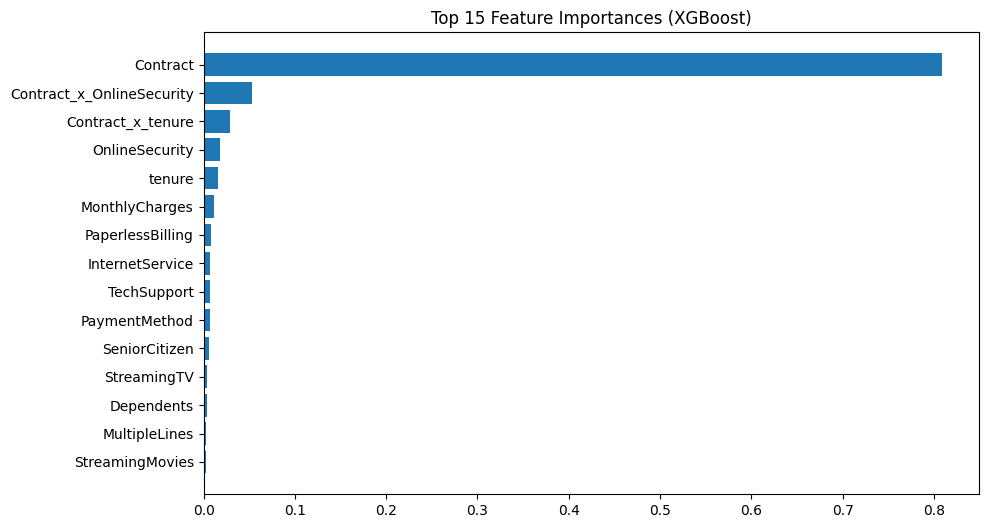

In [22]:
xgb_interact.fit(X_interact, y)
imp_interact = pd.DataFrame({'feature': X_interact.columns, 'importance': xgb_interact.feature_importances_}).sort_values('importance', ascending=False)
print(imp_interact.head(15))

# Plot top 15
plt.figure(figsize=(10,6))
plt.barh(imp_interact.head(15)['feature'], imp_interact.head(15)['importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (XGBoost)')
plt.show()

In [25]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

xgb_tune = XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)
random_search = RandomizedSearchCV(xgb_tune, param_dist, n_iter=50, cv=skf, scoring='roc_auc', random_state=42, n_jobs=-1, verbose=1)
random_search.fit(X_interact, y)  # Use best feature set (with or without interactions)
print("Best AUC:", random_search.best_score_)
print("Best params:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:49:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:49:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:49:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:49:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [04:50:04] WARNING: /w

Best AUC: 0.916159658315072
Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [36]:
print(test_interact.columns)
print(X_interact.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'tenure_group', 'avg_monthly',
       'PhoneService_bin', 'MultipleLines_bin', 'OnlineSecurity_bin',
       'OnlineBackup_bin', 'DeviceProtection_bin', 'TechSupport_bin',
       'StreamingTV_bin', 'StreamingMovies_bin', 'service_count',
       'has_internet', 'tenure_sq', 'monthly_sq', 'tenure_x_monthly',
       'Contract_x_tenure', 'Contract_x_MonthlyCharges',
       'Contract_x_TotalCharges', 'Contract_x_OnlineSecurity',
       'Contract_x_TechSupport', 'tenure_x_MonthlyCharges'],
      dtype='object')
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'O

In [39]:
# Assuming you have:
# X_interact : training features with interactions (created earlier)
# y          : target
# test_enc   : test features before interactions

# --- Train final model with best params ---
best_params = {
    'subsample': 0.6,
    'reg_lambda': 1,
    'reg_alpha': 0,
    'n_estimators': 300,
    'max_depth': 5,
    'learning_rate': 0.1,
    'gamma': 0.2,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
    # 'use_label_encoder': False  # optional, can remove to avoid warning
}

final_model = XGBClassifier(**best_params)
final_model.fit(X_interact, y)

# After creating test_interact, reorder columns to match training set
test_interact = test_interact[X_interact.columns]

# Now check that they match
assert test_interact.columns.equals(X_interact.columns), "Columns still don't match!"

# Predict
test_preds = final_model.predict_proba(test_interact)[:, 1]
# --- Create submission file ---
# Load original test.csv to get ids
test_original = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
submission = pd.DataFrame({
    'id': test_original['id'],
    'Churn': test_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission saved! Head:")
print(submission.head())

Submission saved! Head:
       id     Churn
0  594194  0.071607
1  594195  0.000574
2  594196  0.098550
3  594197  0.003406
4  594198  0.501432


In [54]:
# from lightgbm import LGBMClassifier
# lgb = LGBMClassifier(random_state=42, verbose=-1)
# scores = cross_val_score(lgb, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
# print(f"LightGBM CV AUC: {np.mean(scores):.5f} (+/- {np.std(scores):.5f})")

LightGBM CV AUC: 0.91525 (+/- 0.00087)
